# 01 · Architecture and Parameter Counting

**Goal:** be able to look at a layer-size list such as `[784, 128, 64, 10]` and immediately say how many parameters, how much memory and how much compute the network needs.

**Key formula** (fully-connected layer $l$ with $n_{l-1}$ inputs and $n_l$ outputs):

$$\#\text{params}_l = \underbrace{n_{l-1}\,n_l}_{\text{weights } W^{[l]}} + \underbrace{n_l}_{\text{biases } b^{[l]}}$$

Convention used in this whole section: a batch is a matrix $X \in \mathbb{R}^{N\times d}$ (one **row** per sample), and $W^{[l]}\in\mathbb{R}^{n_{l-1}\times n_l}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

## 1. Counting by hand, then in code
Every neuron in layer $l$ is connected to **every** neuron in layer $l-1$ (that is what "fully connected / dense" means) and owns one bias.

In [2]:
def count_params(sizes):
    """sizes = [n_0 (inputs), n_1, ..., n_L (outputs)] -> per-layer rows and total."""
    rows, total = [], 0
    for l, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:]), start=1):
        w, b = n_in * n_out, n_out
        rows.append(dict(layer=l, shape=(n_in, n_out), weights=w, biases=b, total=w + b))
        total += w + b
    return rows, total


def show(sizes):
    rows, total = count_params(sizes)
    print(f"{'layer':<7}{'W shape':<14}{'weights':>10}{'biases':>8}{'total':>10}")
    for r in rows:
        print(f"{r['layer']:<7}{str(r['shape']):<14}{r['weights']:>10,}{r['biases']:>8,}{r['total']:>10,}")
    print(f"{'TOTAL':<29}{'':>8}{total:>10,}")
    return rows, total


sizes = [784, 128, 64, 10]          # MNIST-style classifier
rows, total = show(sizes)

layer  W shape          weights  biases     total
1      (784, 128)       100,352     128   100,480
2      (128, 64)          8,192      64     8,256
3      (64, 10)             640      10       650
TOTAL                                   109,386


## 2. Verify the formula by actually allocating the arrays

In [3]:
rng = np.random.default_rng(0)
params = [(rng.normal(0, 0.01, (i, o)), np.zeros(o)) for i, o in zip(sizes[:-1], sizes[1:])]

actual = sum(W.size + b.size for W, b in params)
print("formula :", total)
print("arrays  :", actual)
assert actual == total

formula : 109386
arrays  : 109386


## 3. Where do the parameters live?
In networks with large inputs the **first layer dominates** – here it holds ~92 % of all parameters.

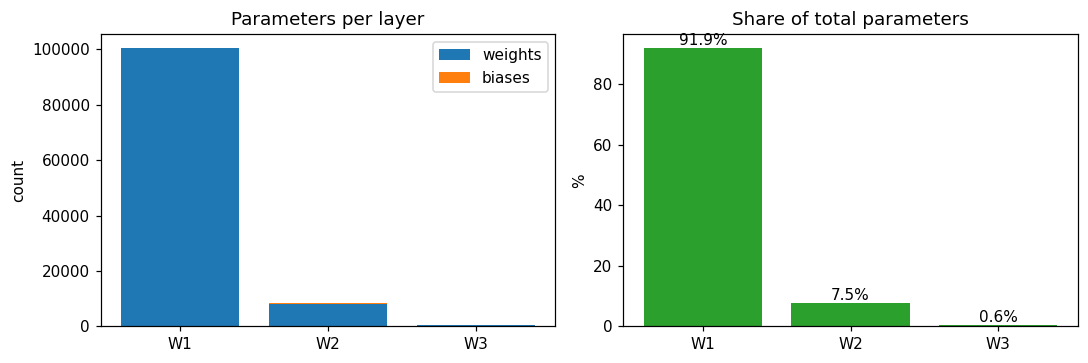

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
names = [f"W{r['layer']}" for r in rows]
w = np.array([r["weights"] for r in rows]); b = np.array([r["biases"] for r in rows])

ax[0].bar(names, w, label="weights")
ax[0].bar(names, b, bottom=w, label="biases")
ax[0].set_title("Parameters per layer"); ax[0].set_ylabel("count"); ax[0].legend()

share = 100 * (w + b) / (w + b).sum()
bars = ax[1].bar(names, share, color="tab:green")
ax[1].bar_label(bars, fmt="%.1f%%")
ax[1].set_title("Share of total parameters"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()

## 4. Width vs depth – same input/output, very different budgets

In [5]:
configs = {
    "wide & shallow   784-512-10":        [784, 512, 10],
    "narrow & deep    784-128x4-10":      [784, 128, 128, 128, 128, 10],
    "bottleneck       784-256-32-256-10": [784, 256, 32, 256, 10],
    "tiny             784-32-10":         [784, 32, 10],
}
for name, s in configs.items():
    _, t = count_params(s)
    print(f"{name:<36}{t:>9,} params   ({4 * t / 1e6:5.2f} MB in fp32)")

wide & shallow   784-512-10           407,050 params   ( 1.63 MB in fp32)
narrow & deep    784-128x4-10         151,306 params   ( 0.61 MB in fp32)
bottleneck       784-256-32-256-10    220,202 params   ( 0.88 MB in fp32)
tiny             784-32-10             25,450 params   ( 0.10 MB in fp32)


## 5. Beyond parameters: activations and FLOPs
* **Multiply-accumulates (MACs)** for one forward pass of a sample: $\sum_l n_{l-1} n_l$ (≈ the weight count!). One MAC = 2 FLOPs.
* **Activations** that must be stored for backprop: $\sum_l n_l$ per sample (times 2 if you store both $Z$ and $A$).

In [6]:
def forward_cost(sizes, batch=1):
    macs = batch * sum(i * o for i, o in zip(sizes[:-1], sizes[1:]))
    acts = batch * sum(sizes[1:])
    return 2 * macs, acts

for B in (1, 256):
    flops, acts = forward_cost(sizes, B)
    print(f"batch={B:<4} forward FLOPs = {flops:>12,}   stored activations = {acts:>9,} numbers")

batch=1    forward FLOPs =      218,368   stored activations =       202 numbers
batch=256  forward FLOPs =   55,902,208   stored activations =    51,712 numbers


## 6. Exercise: size a network to a parameter budget
Given a budget, what hidden width $H$ can a `[784, H, H, 10]` network afford?

In [7]:
def hidden_width_for_budget(n_in, n_out, budget, n_hidden=2):
    best = None
    for H in range(1, 5000):
        _, t = count_params([n_in] + [H] * n_hidden + [n_out])
        if t <= budget:
            best = (H, t)
    return best

for budget in (100_000, 1_000_000):
    H, t = hidden_width_for_budget(784, 10, budget)
    print(f"budget {budget:>9,} -> H = {H:>4}  ({t:,} params)")

budget   100,000 -> H =  110  (99,670 params)
budget 1,000,000 -> H =  678  (999,382 params)


### Try it yourself
1. Count the parameters of `[3072, 512, 256, 100]` (CIFAR-100 on flattened pixels) by hand, then check with `show`.
2. What happens to the parameter count if you remove biases? Is it a big change?
3. Add `batch norm` (2 learnable parameters per feature: $\gamma,\beta$) to every hidden layer – how many extra parameters?